In [1]:
from langgraph.graph import StateGraph, START, MessagesState
from langchain_groq import ChatGroq
from dotenv import load_dotenv

c:\Users\91815\Desktop\learningLANGGRAPH\.venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [2]:
load_dotenv()

True

In [3]:
model=ChatGroq(model="openai/gpt-oss-120b")

In [4]:
# MessagesState is a special state type that automatically includes a messages field. This field is a list of messages (like human or AI messages) and already includes a reducer that appends new messages as the state is updated.
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {
        "messages": [response]
        }

In [5]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

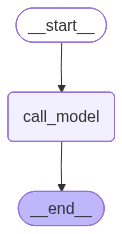

In [6]:
graph= builder.compile()
graph

In [7]:
graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Bhavya."}]})

{'messages': [HumanMessage(content='Hi! My name is Bhavya.', additional_kwargs={}, response_metadata={}, id='c6b2fe42-4850-4683-93b0-9bde8b761db5'),
  AIMessage(content='Hello, Bhavya! Nice to meet you. How can I assist you today?', additional_kwargs={'reasoning_content': 'The user says "Hi! My name is Bhavya." Likely a greeting, maybe they want a response. We should respond politely, maybe ask how can help. Should follow guidelines: be friendly. No disallowed content. So answer: greet back.'}, response_metadata={'token_usage': {'completion_tokens': 81, 'prompt_tokens': 80, 'total_tokens': 161, 'completion_time': 0.169651301, 'completion_tokens_details': {'reasoning_tokens': 54}, 'prompt_time': 0.003201711, 'prompt_tokens_details': None, 'queue_time': 0.054597188, 'total_time': 0.172853012}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_4a19b1544c', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e6579-7

In [8]:
# this is without the persistence inmemory saver
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]})

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='39a676d5-590d-47b1-bdc9-9398afb28660'),
  AIMessage(content='I don’t have any information about your name. If you’d like me to address you by a specific name, just let me know!', additional_kwargs={'reasoning_content': 'The user asks "What is my name?" We have no prior context. We must follow policy: cannot guess personal info. We should respond that we don\'t know. Possibly ask if they\'d like to share. So answer: I don\'t know your name. If you tell me, I can address.'}, response_metadata={'token_usage': {'completion_tokens': 97, 'prompt_tokens': 76, 'total_tokens': 173, 'completion_time': 0.209698107, 'completion_tokens_details': {'reasoning_tokens': 60}, 'prompt_time': 0.002885318, 'prompt_tokens_details': None, 'queue_time': 0.049564496, 'total_time': 0.212583425}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_a09bde29de', 'service_tier': 'on_demand', 'finish_rea

In [9]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}
    

In [10]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [11]:
#Introduced the inmemorysaver this is called a ram memory saver when ram gets cleared the message too.
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [16]:
config = {"configurable":{"thread_id":"thread1"}}
config2 = {"configurable":{"thread_id":"thread2"}}

In [13]:
graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is bhavya."}]}, config)

{'messages': [HumanMessage(content='Hi! My name is bhavya.', additional_kwargs={}, response_metadata={}, id='5fc7c536-fad0-4a25-9b02-360ee0ed5b3e'),
  AIMessage(content='Hello, Bhavya! Nice to meet you. How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "Hi! My name is bhavya." The assistant should respond appropriately, greeting and possibly asking how can help. There\'s no disallowed content. So just friendly.'}, response_metadata={'token_usage': {'completion_tokens': 65, 'prompt_tokens': 80, 'total_tokens': 145, 'completion_time': 0.141872682, 'completion_tokens_details': {'reasoning_tokens': 38}, 'prompt_time': 0.002987366, 'prompt_tokens_details': None, 'queue_time': 0.055823874, 'total_time': 0.144860048}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_a09bde29de', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e6579-75e2-74d1-9077-b6931655b83c-0', tool_calls=[], inv

In [ ]:
graph.invoke({"messages":[{"role":"user","content":"wht is my name"}]},config=config)


{'messages': [HumanMessage(content='Hi! My name is bhavya.', additional_kwargs={}, response_metadata={}, id='5fc7c536-fad0-4a25-9b02-360ee0ed5b3e'),
  AIMessage(content='Hello, Bhavya! Nice to meet you. How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "Hi! My name is bhavya." The assistant should respond appropriately, greeting and possibly asking how can help. There\'s no disallowed content. So just friendly.'}, response_metadata={'token_usage': {'completion_tokens': 65, 'prompt_tokens': 80, 'total_tokens': 145, 'completion_time': 0.141872682, 'completion_tokens_details': {'reasoning_tokens': 38}, 'prompt_time': 0.002987366, 'prompt_tokens_details': None, 'queue_time': 0.055823874, 'total_time': 0.144860048}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_a09bde29de', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e6579-75e2-74d1-9077-b6931655b83c-0', tool_calls=[], inv

In [ ]:
graph.invoke({"messages":[{"role":"user","content":"wht is my name"}]},config=config2)
# see in this the inmemorysaver is thread scope if u change the threadid its new

{'messages': [HumanMessage(content='wht is my name', additional_kwargs={}, response_metadata={}, id='187a1664-c127-4f92-ae84-74b6ce6411a6'),
  AIMessage(content='I don’t have any information about your name. If you’d like, you can tell me what you’d like to be called, and I’ll use that in our conversation!', additional_kwargs={'reasoning_content': 'The user asks "wht is my name". There\'s no prior conversation giving the name. According to policy, we must not fabricate personal info. We can respond that we don\'t know their name. Ask if they\'d like to tell us.'}, response_metadata={'token_usage': {'completion_tokens': 93, 'prompt_tokens': 76, 'total_tokens': 169, 'completion_time': 0.195768959, 'completion_tokens_details': {'reasoning_tokens': 48}, 'prompt_time': 0.003967371, 'prompt_tokens_details': None, 'queue_time': 0.054839799, 'total_time': 0.19973633}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_8a618bed98', 'service_tier': 'on_demand', 'finish_reason': 'stop

In [ ]:
# the problem with the inmemory saver is if the ram gets cleared the data to it doesn't hold the previous conversation 